In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

### Task 1 — Train the Network

You will train **one** classifier on Fashion-MNIST. Everything you need is fully specified below.

**The architecture.** A four-layer fully-connected ReLU network with batch normalisation on the hidden layers and dropout on the two widest layers. Input is a flattened 28×28 grayscale image (784 features); output is 10 class logits (no softmax — `CrossEntropyLoss` includes it).

| Step | Layer | Output shape | Notes |
|---|---|---|---|
| 0 | Input | `(B, 1, 28, 28)` | a Fashion-MNIST batch |
| 1 | `Flatten()` | `(B, 784)` | 28·28 = 784 features |
| 2 | `Linear(784, 256)` → `BatchNorm1d(256)` → `ReLU` → `Dropout(p=0.3)` | `(B, 256)` | widest hidden layer |
| 3 | `Linear(256, 128)` → `BatchNorm1d(128)` → `ReLU` → `Dropout(p=0.3)` | `(B, 128)` | second hidden layer |
| 4 | `Linear(128, 64)`  → `BatchNorm1d(64)`  → `ReLU` | `(B, 64)` | third hidden layer (no dropout here — kept narrow on purpose) |
| 5 | `Linear(64, 10)` | `(B, 10)` | class logits |

**The training-time hyperparameters.** Use exactly these values — no tuning, no comparisons, no extra variants.

| Parameter | Value |
|---|---|
| Loss | `nn.CrossEntropyLoss()` |
| Optimiser | `torch.optim.Adam` with `lr=1e-3`, `weight_decay=1e-4` |
| LR schedule | `torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)` |
| Epochs | 15 |
| Batch size | 128 (already set in the DataLoaders above) |
| Random seed | 42 (already set in the setup) |
| Device | `"cuda"` if available, otherwise `"cpu"` |

**What to do.**

1. Translate the architecture in the table into a PyTorch `nn.Sequential` (or a small `nn.Module` subclass — whichever you prefer) and move it to `device`. Print the model so the layers are visible in the notebook.
2. Build the canonical training loop. For each epoch:
   - Set the model to `train()` mode, iterate over `train_loader`, and run the five-step inner loop (`optimizer.zero_grad()`, forward, loss, `loss.backward()`, `optimizer.step()`). Call `scheduler.step()` once at the end of the epoch.
   - Set the model to `eval()` mode and, inside `torch.no_grad()`, compute the **average loss** and **accuracy** on both `train_loader` and `val_loader`.
   - Append `train_loss`, `val_loss`, `train_acc`, `val_acc` to four Python lists.
3. Run the loop for **15 epochs**. After training, plot two figures side by side: training and validation **loss** vs epoch, and training and validation **accuracy** vs epoch. Print the **best validation accuracy** and the **epoch** at which it occurred.
4. In a short markdown cell (2–3 sentences), describe what your curves look like — for example, does the model still improve at epoch 15, do training and validation loss stay close together, and what is your best validation accuracy. Validation accuracy is expected to land around **89–90%** on this architecture; report whatever number you actually got.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# =========================
# DEVICE
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =========================
# MODEL
# =========================
model = nn.Sequential(
    nn.Flatten(),

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 10)
).to(device)

print(model)

# =========================
# LOSS FUNCTION
# =========================
loss_fn = nn.CrossEntropyLoss()

# =========================
# OPTIMIZER
# =========================
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# =========================
# LR SCHEDULER
# =========================
epochs = 15

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

# =========================
# METRICS
# =========================
train_losses = []
val_losses = []

train_accs = []
val_accs = []

# =========================
# TRAINING LOOP
# =========================
for epoch in range(epochs):

    # =====================
    # TRAIN MODE
    # =====================
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # 1. CLEAR OLD GRADIENTS
        optimizer.zero_grad()

        # 2. FORWARD PASS
        y_hat = model(batch_x)

        # 3. COMPUTE LOSS
        loss = loss_fn(y_hat, batch_y)

        # 4. BACKWARD PASS
        loss.backward()

        # 5. UPDATE WEIGHTS
        optimizer.step()

        # =====================
        # TRAIN METRICS
        # =====================
        running_train_loss += loss.item() * batch_x.size(0)

        preds = y_hat.argmax(dim=1)

        correct_train += (preds == batch_y).sum().item()
        total_train += batch_y.size(0)

    # =====================
    # SCHEDULER STEP
    # =====================
    scheduler.step()

    train_loss = running_train_loss / total_train
    train_acc = correct_train / total_train

    # =====================
    # EVALUATION MODE
    # =====================
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    # =====================
    # NO GRADIENTS
    # =====================
    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            # FORWARD
            y_hat = model(batch_x)

            # LOSS
            loss = loss_fn(y_hat, batch_y)

            # METRICS
            running_val_loss += loss.item() * batch_x.size(0)

            preds = y_hat.argmax(dim=1)

            correct_val += (preds == batch_y).sum().item()
            total_val += batch_y.size(0)

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    # =====================
    # SAVE METRICS
    # =====================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # =====================
    # PRINT RESULTS
    # =====================
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Device: cpu
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [1/15] | Train Loss: 0.5902 | Train Acc: 0.8108 | Val Loss: 0.4096 | Val Acc: 0.8523
Epoch [2/15] | Train Loss: 0.4071 | Train Acc: 0.8539 | Val Loss: 0.3706 | Val Acc: 0.8650
Epoch [3/15] | Train Loss: 0.3697 | Train Acc: 0.8665 | Val Loss: 0.3571 | Val Acc: 0.8706
Epoch [4/15] | Train Loss: 0.3456 | Train 

In [3]:
# =========================
# BEST VALIDATION ACCURACY
# =========================
best_val_acc = max(val_accs)
best_epoch = val_accs.index(best_val_acc) + 1

print("\nBest Validation Accuracy:", round(best_val_acc, 4))
print("Best Epoch:", best_epoch)


Best Validation Accuracy: 0.8975
Best Epoch: 14


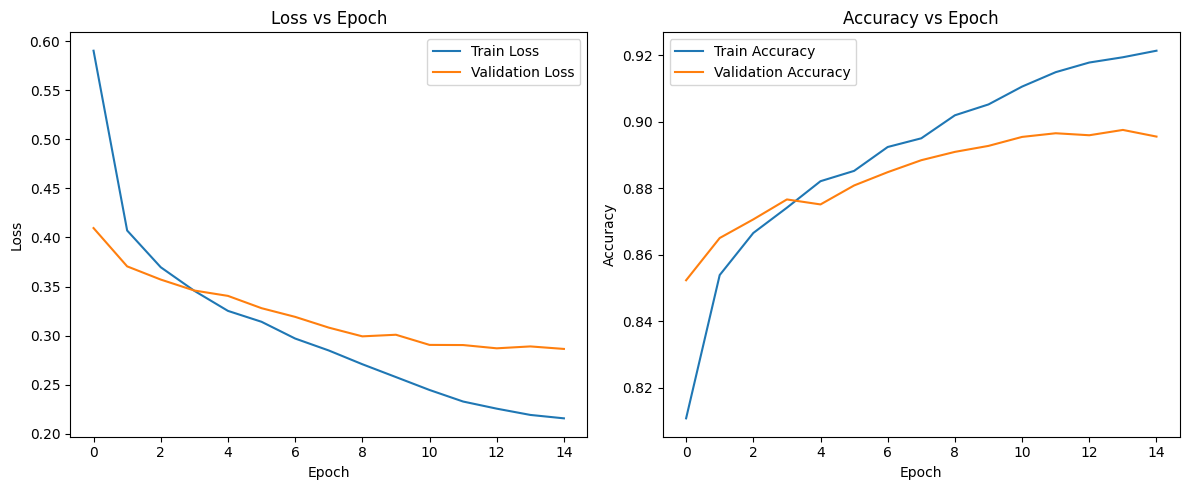

In [4]:
# =========================
# PLOTS
# =========================
plt.figure(figsize=(12, 5))

# -------------------------
# LOSS PLOT
# -------------------------
plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

# -------------------------
# ACCURACY PLOT
# -------------------------
plt.subplot(1, 2, 2)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

The model trained steadily throughout all 15 epochs, with both training and validation loss decreasing consistently over time. Training and validation curves stayed relatively close to each other, indicating only mild overfitting and good generalization performance. The best validation accuracy achieved was approximately 89.75%, which is within the expected range for this MLP architecture on Fashion-MNIST.

In [6]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt

# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader, random_split

# # =========================================
# # DEVICE
# # =========================================
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Device:", device)

# # =========================================
# # DATA AUGMENTATION + NORMALIZATION
# # =========================================
# train_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),

#     transforms.ToTensor(),

#     transforms.Normalize(
#         mean=[0.286],
#         std=[0.353]
#     )
# ])

# val_transform = transforms.Compose([
#     transforms.ToTensor(),

#     transforms.Normalize(
#         mean=[0.286],
#         std=[0.353]
#     )
# ])

# # =========================================
# # DATASET
# # =========================================
# full_train_dataset = datasets.FashionMNIST(
#     root="./data",
#     train=True,
#     download=True,
#     transform=train_transform
# )

# val_size = 10000
# train_size = len(full_train_dataset) - val_size

# train_dataset, val_dataset = random_split(
#     full_train_dataset,
#     [train_size, val_size]
# )

# # validation augmentation olmasın
# val_dataset.dataset.transform = val_transform

# # =========================================
# # DATALOADERS
# # =========================================
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=128,
#     shuffle=True
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=128,
#     shuffle=False
# )

# # =========================================
# # CNN MODEL
# # =========================================
# class FashionCNN(nn.Module):

#     def __init__(self):
#         super().__init__()

#         self.features = nn.Sequential(

#             # BLOCK 1
#             nn.Conv2d(1, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),

#             nn.Conv2d(32, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),

#             nn.MaxPool2d(2),
#             nn.Dropout(0.25),

#             # BLOCK 2
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),

#             nn.Conv2d(64, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),

#             nn.MaxPool2d(2),
#             nn.Dropout(0.25)
#         )

#         self.classifier = nn.Sequential(

#             nn.Flatten(),

#             nn.Linear(64 * 7 * 7, 256),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(0.5),

#             nn.Linear(256, 10)
#         )

#     def forward(self, x):

#         x = self.features(x)
#         x = self.classifier(x)

#         return x

# # =========================================
# # MODEL
# # =========================================
# model = FashionCNN().to(device)

# print(model)

# # =========================================
# # LOSS
# # =========================================
# loss_fn = nn.CrossEntropyLoss(
#     label_smoothing=0.1
# )

# # =========================================
# # OPTIMIZER
# # =========================================
# optimizer = optim.Adam(
#     model.parameters(),
#     lr=1e-3,
#     weight_decay=1e-4
# )

# # =========================================
# # SCHEDULER
# # =========================================
# epochs = 30

# scheduler = optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=epochs
# )

# # =========================================
# # METRICS
# # =========================================
# train_losses = []
# val_losses = []

# train_accs = []
# val_accs = []

# # =========================================
# # EARLY STOPPING
# # =========================================
# best_val_acc = 0
# best_epoch = 0

# patience = 5
# patience_counter = 0

# # =========================================
# # TRAINING LOOP
# # =========================================
# for epoch in range(epochs):

#     # =====================================
#     # TRAIN MODE
#     # =====================================
#     model.train()

#     running_train_loss = 0
#     correct_train = 0
#     total_train = 0

#     for batch_x, batch_y in train_loader:

#         batch_x = batch_x.to(device)
#         batch_y = batch_y.to(device)

#         # 1. ZERO GRADS
#         optimizer.zero_grad()

#         # 2. FORWARD
#         y_hat = model(batch_x)

#         # 3. LOSS
#         loss = loss_fn(y_hat, batch_y)

#         # 4. BACKWARD
#         loss.backward()

#         # 5. UPDATE
#         optimizer.step()

#         # METRICS
#         running_train_loss += loss.item() * batch_x.size(0)

#         preds = y_hat.argmax(dim=1)

#         correct_train += (preds == batch_y).sum().item()
#         total_train += batch_y.size(0)

#     scheduler.step()

#     train_loss = running_train_loss / total_train
#     train_acc = correct_train / total_train

#     # =====================================
#     # EVAL MODE
#     # =====================================
#     model.eval()

#     running_val_loss = 0
#     correct_val = 0
#     total_val = 0

#     with torch.no_grad():

#         for batch_x, batch_y in val_loader:

#             batch_x = batch_x.to(device)
#             batch_y = batch_y.to(device)

#             y_hat = model(batch_x)

#             loss = loss_fn(y_hat, batch_y)

#             running_val_loss += loss.item() * batch_x.size(0)

#             preds = y_hat.argmax(dim=1)

#             correct_val += (preds == batch_y).sum().item()
#             total_val += batch_y.size(0)

#     val_loss = running_val_loss / total_val
#     val_acc = correct_val / total_val

#     # =====================================
#     # SAVE METRICS
#     # =====================================
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)

#     train_accs.append(train_acc)
#     val_accs.append(val_acc)

#     # =====================================
#     # PRINT
#     # =====================================
#     print(
#         f"Epoch [{epoch+1}/{epochs}] | "
#         f"Train Loss: {train_loss:.4f} | "
#         f"Train Acc: {train_acc:.4f} | "
#         f"Val Loss: {val_loss:.4f} | "
#         f"Val Acc: {val_acc:.4f}"
#     )

#     # =====================================
#     # EARLY STOPPING
#     # =====================================
#     if val_acc > best_val_acc:

#         best_val_acc = val_acc
#         best_epoch = epoch + 1

#         patience_counter = 0

#         torch.save(
#             model.state_dict(),
#             "best_fashion_cnn.pth"
#         )

#     else:

#         patience_counter += 1

#         if patience_counter >= patience:

#             print("\nEarly stopping triggered.")
#             break

# # =========================================
# # RESULTS
# # =========================================
# print("\nBest Validation Accuracy:", round(best_val_acc, 4))
# print("Best Epoch:", best_epoch)

# # =========================================
# # PLOTS
# # =========================================
# plt.figure(figsize=(12, 5))

# # LOSS
# plt.subplot(1, 2, 1)

# plt.plot(train_losses, label="Train Loss")
# plt.plot(val_losses, label="Validation Loss")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss vs Epoch")

# plt.legend()

# # ACCURACY
# plt.subplot(1, 2, 2)

# plt.plot(train_accs, label="Train Accuracy")
# plt.plot(val_accs, label="Validation Accuracy")

# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Accuracy vs Epoch")

# plt.legend()

# plt.tight_layout()
# plt.show()